<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Fall_2025/blob/main/Module%206/30_DeepDream.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeepDream & Feature Visualization


In [10]:
!gdown https://drive.google.com/uc?id=1e9qvvitE0e5FRz1kGpR-4k8vRv6i9Zbp

import tensorflow as tf
cat_image = tf.io.read_file('/content/cute.jpg')
cat_image = tf.image.decode_jpeg(cat_image)
cat_image = tf.image.resize(cat_image, (299, 299))  # Resize to match InceptionV3 input size

Downloading...
From: https://drive.google.com/uc?id=1e9qvvitE0e5FRz1kGpR-4k8vRv6i9Zbp
To: /content/cute.jpg
100% 140k/140k [00:00<00:00, 95.6MB/s]


In [11]:
!pip install lime

# Deep Dream

## MNIST on simple DCNN

In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Load MNIST data
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1)).astype('float32') / 255

# Build a simple CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile and train the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, batch_size=64, verbose=1)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 62ms/step - accuracy: 0.8687 - loss: 0.4254
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.9835 - loss: 0.0547
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9880 - loss: 0.0375
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 47ms/step - accuracy: 0.9913 - loss: 0.0264
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 49ms/step - accuracy: 0.9938 - loss: 0.0195


In [13]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)

0 conv2d_97
1 max_pooling2d_6
2 conv2d_98
3 max_pooling2d_7
4 conv2d_99
5 flatten_1
6 dense_2
7 dense_3


In [14]:
vals = [0, 0, 8, 0, 0, 0, 0]
layer_dict = {}

conv_counter = 0  # Counter for layers starting with 'conv'
for layer in model.layers:
    if layer.name.startswith('conv'):
        if conv_counter < len(vals):
            print(layer.name, vals[conv_counter])
            layer_dict[layer.name] = vals[conv_counter]
            conv_counter += 1

print(layer_dict)


conv2d_97 0
conv2d_98 0
conv2d_99 8
{'conv2d_97': 0, 'conv2d_98': 0, 'conv2d_99': 8}


In [15]:
import numpy as np, tensorflow as tf, matplotlib.pyplot as plt

# 1) Functional clone + capture per-layer tensors as we build it
inp = tf.keras.Input(shape=(28, 28, 1))
x = inp
tensor_by_name = {}   # <-- capture outputs tied to THIS graph
for lyr in model.layers:         # reuse trained layers from your Sequential model
    x = lyr(x)
    tensor_by_name[lyr.name] = x
fmodel = tf.keras.Model(inp, x)
print("Functional model ready:", fmodel.input.shape)

# 2) Choose conv layers and coefficients
layer_coeffs = {"conv2d": 1.0, "conv2d_1": 0.5, "conv2d_2": 0.25}
target_layers = [n for n in layer_coeffs if n in tensor_by_name and n.startswith("conv")]
if not target_layers:
    raise ValueError("No valid conv layers found in tensor_by_name.")
print("Using layers:", target_layers)

# 3) Build dream_model using the CAPTURED tensors (no get_layer, no layer.output)
dream_model = tf.keras.Model(
    inputs=fmodel.input,
    outputs=[tensor_by_name[n] for n in target_layers]
)

# 4) DeepDream
def deepdream(image, steps=60, step_size=0.02):
    """
    image: (1,28,28,1) in [0,1]
    """
    x = tf.Variable(tf.convert_to_tensor(image, dtype=tf.float32))
    for _ in range(steps):
        with tf.GradientTape() as tape:
            outputs = dream_model(x)
            if not isinstance(outputs, (list, tuple)):
                outputs = [outputs]
            loss = tf.add_n([
                tf.constant(layer_coeffs[n], tf.float32) * tf.reduce_mean(tf.square(o))
                for n, o in zip(target_layers, outputs)
            ])
        grads = tape.gradient(loss, x)
        grads /= tf.maximum(tf.reduce_mean(tf.abs(grads)), 1e-8)
        x.assign_add(step_size * grads)
        x.assign(tf.clip_by_value(x, 0.0, 1.0))  # keep MNIST range
    return x.numpy()

# 5) Run on one test image
idx = np.random.randint(len(test_images))
orig = test_images[idx:idx+1].astype("float32")
dreamed = deepdream(orig, steps=60, step_size=0.02)

# 6) Show
plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(orig.squeeze(), cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(dreamed.squeeze(), cmap="gray"); plt.title("DeepDream"); plt.axis("off")
plt.show()


Functional model ready: (None, 28, 28, 1)


ValueError: No valid conv layers found in tensor_by_name.

## Cat on ImageNet

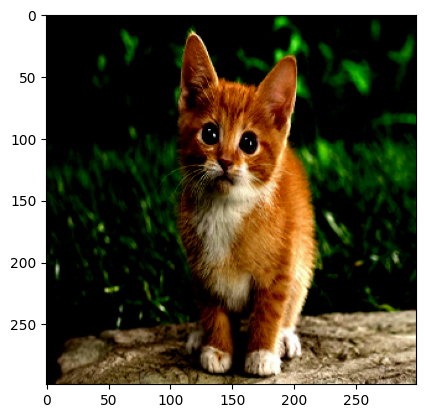

In [16]:
from tensorflow.keras.applications.inception_v3 import preprocess_input

cat_image = tf.io.read_file('/content/cute.jpg')
cat_image = tf.image.decode_jpeg(cat_image)
cat_image = tf.image.resize(cat_image, (299, 299))  # Resize to match InceptionV3 input size
cat_image = tf.cast(cat_image, tf.float32)
cat_image = preprocess_input(cat_image)
cat_image = tf.expand_dims(cat_image, axis=0)  # Add batch dimension

plt.imshow(cat_image[0,:,:,:])

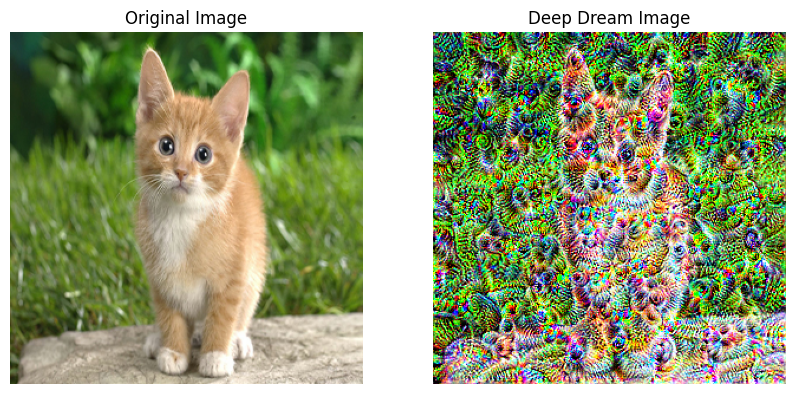

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10 data
(x_train, _), (_, _) = cifar10.load_data()

# Select a random image from CIFAR-10
img = x_train[np.random.randint(len(x_train))]
img = tf.image.resize(img, (299, 299))  # Resize to match InceptionV3 input size

# Convert to float and preprocess for InceptionV3
img = tf.cast(img, tf.float32)
img = preprocess_input(img)
img = tf.expand_dims(img, axis=0)  # Add batch dimension

# Load InceptionV3 model pre-trained on ImageNet
base_model = InceptionV3(weights='imagenet', include_top=False)

# Maximize the activations of these layers
names = ['mixed2', 'mixed3', 'mixed4']
layers = [base_model.get_layer(name).output for name in names]

# Create the feature extraction model
deepdream_model = tf.keras.Model(inputs=base_model.input, outputs=layers)

def calculate_loss(image, model):
    layer_activations = model(image)
    losses = [tf.math.reduce_mean(act) for act in layer_activations]
    return tf.reduce_sum(losses)

@tf.function
def deepdream_step(img, model, learning_rate):
    with tf.GradientTape() as tape:
        tape.watch(img)
        loss = calculate_loss(img, model)
    gradients = tape.gradient(loss, img)
    gradients /= tf.math.reduce_std(gradients) + 1e-8
    img = img + gradients * learning_rate
    img = tf.clip_by_value(img, -1, 1)
    return img

def run_deep_dream_simple(model, img, steps=100, learning_rate=0.01):
    for step in range(steps):
        img = deepdream_step(img, model, learning_rate)
    return img

# Run DeepDream
img = cat_image #Comment out if you want to run CIFAR
dream_image = run_deep_dream_simple(deepdream_model, img, steps=50, learning_rate=0.1)

# Show the original and dreamed image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.squeeze(img.numpy() * 0.5 + 0.5))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.squeeze(dream_image.numpy() * 0.5 + 0.5))
plt.title("Deep Dream Image")
plt.axis('off')

plt.show()

In [ ]:
'''
for i, layer in enumerate(base_model.layers):
    print(i, layer.name)
    '''